# 02 - TF-IDF + Linear SVC

**Goal:** Predict song topic (8 classes) from cleaned lyrics using TF-IDF features and a Linear Support Vector Classifier.

**Depends on:** `data/processed/train.csv` and `data/processed/test.csv` produced by `00_preprocessing.ipynb`.

## 1. Imports and setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, f1_score,
                             confusion_matrix)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR     = os.path.join(REPO_ROOT, 'data')

## 2. Load train / test splits

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'processed', 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'processed', 'test.csv'))

X_train, y_train = train_df['lyrics_clean'], train_df['topic_label']
X_test,  y_test  = test_df['lyrics_clean'],  test_df['topic_label']

TOPIC_NAMES = sorted(train_df['topic'].unique())
N_CLASSES   = len(TOPIC_NAMES)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}  |  Classes: {N_CLASSES}')
print('Topics:', TOPIC_NAMES)

Train: 22,233  |  Test: 5,559  |  Classes: 8
Topics: ['feelings', 'music', 'night/time', 'obscene', 'romantic', 'sadness', 'violence', 'world/life']


## 3. TF-IDF vectorisation

In [3]:
# TODO: tune max_features, ngram_range, min_df
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

## 4. Train Linear SVC

> `LinearSVC` performs one-vs-rest multi-class classification by default. Use `decision_function` for per-class scores.

In [4]:
pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', LinearSVC(C=1.0, max_iter=2000, random_state=42))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 5. Evaluate on test set

In [5]:
y_pred   = pipeline.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(classification_report(y_test, y_pred, target_names=TOPIC_NAMES))
print(f'Macro F1: {macro_f1:.4f}')

              precision    recall  f1-score   support

    feelings       0.88      0.74      0.80       116
       music       0.89      0.90      0.90       446
  night/time       0.88      0.85      0.86       354
     obscene       0.94      0.94      0.94       966
    romantic       0.91      0.81      0.86       295
     sadness       0.90      0.92      0.91      1197
    violence       0.90      0.91      0.90      1124
  world/life       0.90      0.91      0.91      1061

    accuracy                           0.90      5559
   macro avg       0.90      0.87      0.89      5559
weighted avg       0.90      0.90      0.90      5559

Macro F1: 0.8854


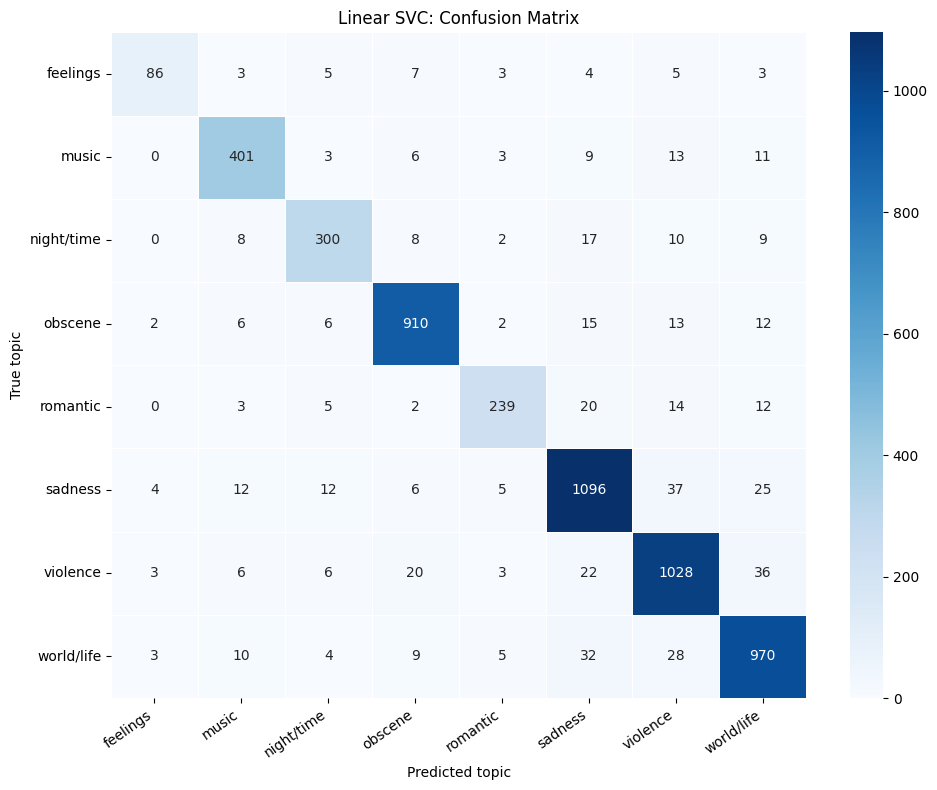

In [6]:
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=TOPIC_NAMES, yticklabels=TOPIC_NAMES,
            cmap='Blues', linewidths=0.4, ax=ax)
ax.set_xlabel('Predicted topic')
ax.set_ylabel('True topic')
ax.set_title('Linear SVC: Confusion Matrix')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'svm_confusion_matrix.png'), dpi=120)
plt.show()

## 5a. Lyric length distribution

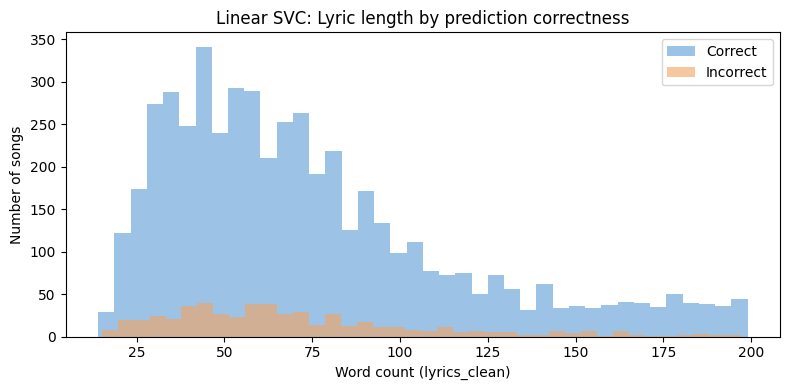

In [7]:
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

correct     = pd.Series(y_pred == y_test.values, index=X_test.index)
word_counts = X_test.str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, mask, color in [
    ('Correct',   correct,  '#5b9bd5'),
    ('Incorrect', ~correct, '#f4a261'),
]:
    ax.hist(word_counts[mask], bins=40, alpha=0.6, color=color, label=label)
ax.set_xlabel('Word count (lyrics_clean)')
ax.set_ylabel('Number of songs')
ax.set_title('Linear SVC: Lyric length by prediction correctness')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'svm_lyric_length_dist.png'), dpi=120)
plt.show()

## 5b. Accuracy per topic

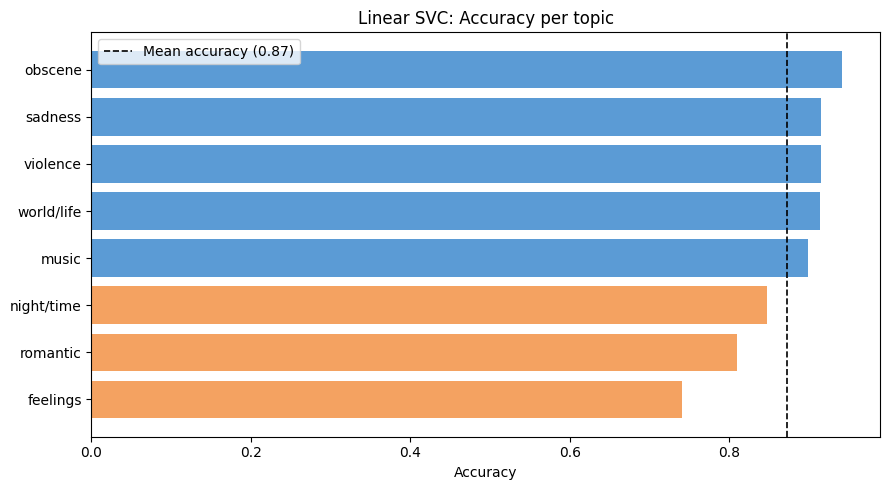

feelings      0.741379
romantic      0.810169
night/time    0.847458
music         0.899103
world/life    0.914232
violence      0.914591
sadness       0.915622
obscene       0.942029


In [8]:
topic_acc = {}
for i, name in enumerate(TOPIC_NAMES):
    mask = y_test.values == i
    if mask.sum() > 0:
        topic_acc[name] = (y_pred[mask] == i).mean()

topic_acc_s = pd.Series(topic_acc).sort_values()
mean_acc    = topic_acc_s.mean()
colors      = ['#5b9bd5' if v >= mean_acc else '#f4a261'
               for v in topic_acc_s.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(topic_acc_s.index, topic_acc_s.values, color=colors)
ax.axvline(mean_acc, color='black', linestyle='--', linewidth=1.2,
           label=f'Mean accuracy ({mean_acc:.2f})')
ax.set_xlabel('Accuracy')
ax.set_title('Linear SVC: Accuracy per topic')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'svm_accuracy_per_topic.png'), dpi=120)
plt.show()

print(topic_acc_s.to_string())

## 5c. Error analysis

In [9]:
errors_df = test_df.copy()
errors_df = errors_df.assign(y_pred=y_pred)
errors_df = errors_df[errors_df['topic_label'] != errors_df['y_pred']]

print(f'Total misclassifications: {len(errors_df):,} / {len(test_df):,} ({len(errors_df)/len(test_df)*100:.1f}%)\n')
sample = errors_df.sample(5, random_state=42)
for _, row in sample.iterrows():
    snippet    = str(row['lyrics_clean'])[:100]
    true_topic = TOPIC_NAMES[int(row['topic_label'])]
    pred_topic = TOPIC_NAMES[int(row['y_pred'])]
    print(f'Snippet    : {snippet}...')
    print(f'True topic : {true_topic:<12}  |  Predicted: {pred_topic}')
    print()

Total misclassifications: 529 / 5,559 (9.5%)

Snippet    : music stop people know songs moment blink world know changin moment moment moment spring singin mome...
True topic : world/life    |  Predicted: music

Snippet    : paint capture canvas portrait stand brush stroke bold soft whisper work feminine hand catch life sur...
True topic : violence      |  Predicted: sadness

Snippet    : joyride little house countryside understand learn demand compromise balance right balance right resp...
True topic : night/time    |  Predicted: sadness

Snippet    : float aby brig head swing beware wrath image go crumble frown spell clear nontradition step piece pa...
True topic : world/life    |  Predicted: sadness

Snippet    : spend time wait second break okay reason feel good hard need distraction beautiful release memory se...
True topic : sadness       |  Predicted: violence



## 6. Top features per class

In [10]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coef  = pipeline.named_steps['clf'].coef_  # shape (n_classes, n_features)
top_n = 15

for cls_idx, cls_name in enumerate(TOPIC_NAMES):
    top_idx = np.argsort(coef[cls_idx])[-top_n:][::-1]
    print(f'\nTop {top_n} features for "{cls_name}":')
    print([feature_names[i] for i in top_idx])


Top 15 features for "feelings":
['go go', 'good', 'feel', 'feel feel', 'good good', 'go', 'somebody somebody', 'miss', 'miss miss', 'real real', 'somebody', 'good morning', 'good feel', 'real', 'morning']

Top 15 features for "music":
['blue', 'hear', 'sing', 'home', 'song', 'summer', 'music', 'play', 'call', 'ring', 'songs', 'guitar', 'home home', 'lonesome', 'blue blue']

Top 15 features for "night/time":
['time', 'night', 'tonight', 'right', 'mind', 'long', 'time time', 'long long', 'night night', 'line', 'ready', 'mind mind', 'ready ready', 'right right', 'late']

Top 15 features for "obscene":
['money', 'fuck', 'party', 'shit', 'gettin', 'bout', 'like', 'better', 'lookin', 'game', 'nothin', 'ball', 'talkin', 'comin', 'damn']

Top 15 features for "romantic":
['hold', 'woman', 'kiss', 'sweet', 'love', 'hold hold', 'thrill', 'arm', 'lover', 'touch', 'darling', 'goodbye', 'dear', 'love love', 'true']

Top 15 features for "sadness":
['heart', 'away', 'fall', 'break', 'leave', 'walk', 

## 7. Save predictions for evaluation notebook

In [11]:
preds_df = pd.DataFrame({
    'topic_label': y_test.values,
    'y_pred':      y_pred,
})
out_path = os.path.join(DATA_DIR, 'preds', 'svm_preds.csv')
preds_df.to_csv(out_path, index=False)
print(f'Saved {len(preds_df):,} rows to {out_path}')

Saved 5,559 rows to /Users/nidhijadhav/Desktop/cs4120/lyrics-to-valence/data/preds/svm_preds.csv
